In [101]:
import random
import astra
import matplotlib.pyplot as plt
from skimage import draw
import numpy as np
from PIL import Image
import os
from os import mkdir
from os.path import isdir
from pathlib import Path
from ReconstructionAlgorithms import SIRT, FBP
from Sinograms import sinogram
astra.test() # if everything works properly you should see information about your GPU and CUDA capability

No GPU support available
Testing basic CPU 2D functionality... Ok


In [ ]:
path = Path.cwd()
path = os.path.join("Pixel_phantom/phantom_arrays")

phantoms = {}
for fname in os.listdir(path):
    if fname.endswith('.npz'):
        data = np.load(fname)
        phantoms[fname.replace('.npz', '')] = data[list(data.keys())[0]]

In [ ]:
def plot(phantom, sinogram_img, sirt_reconstruction,  fbp_reconstruction, figsize=(10, 10)):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
    ax[0, 0].imshow(phantom, cmap='gray')
    ax[0, 1].imshow(sinogram_img, cmap='gray')
    ax[1, 0].imshow(sirt_reconstruction, cmap='gray')
    ax[1, 1].imshow(fbp_reconstruction, cmap='gray')

    ax[0, 0].set_title("Original phantom")
    ax[0, 1].set_title("Sinogram")
    ax[1, 0].set_title("Sirt reconstruction")
    ax[1, 1].set_title("FBP reconstruction")


    ax[0, 0].axis('off')
    ax[0, 1].axis('off')
    ax[1, 0].axis('off')
    ax[1, 1].axis('off')

    fig.tight_layout()

    plt.show()

dict_keys(['multiple_shapes_and_graylevels', 'two_gray_triangle', 'multiple_gray_triangle', 'Overlapping_ellipses', 'Random_geo_shapes', 'binary_triangle'])

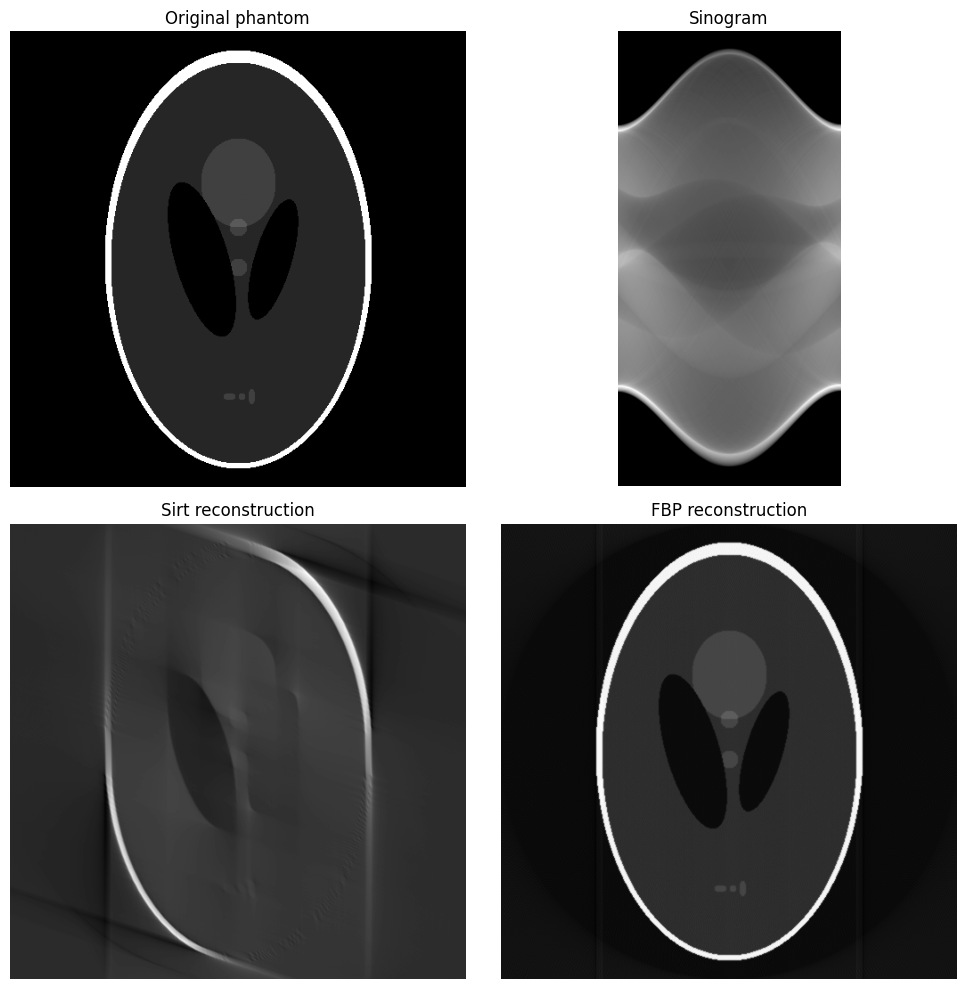

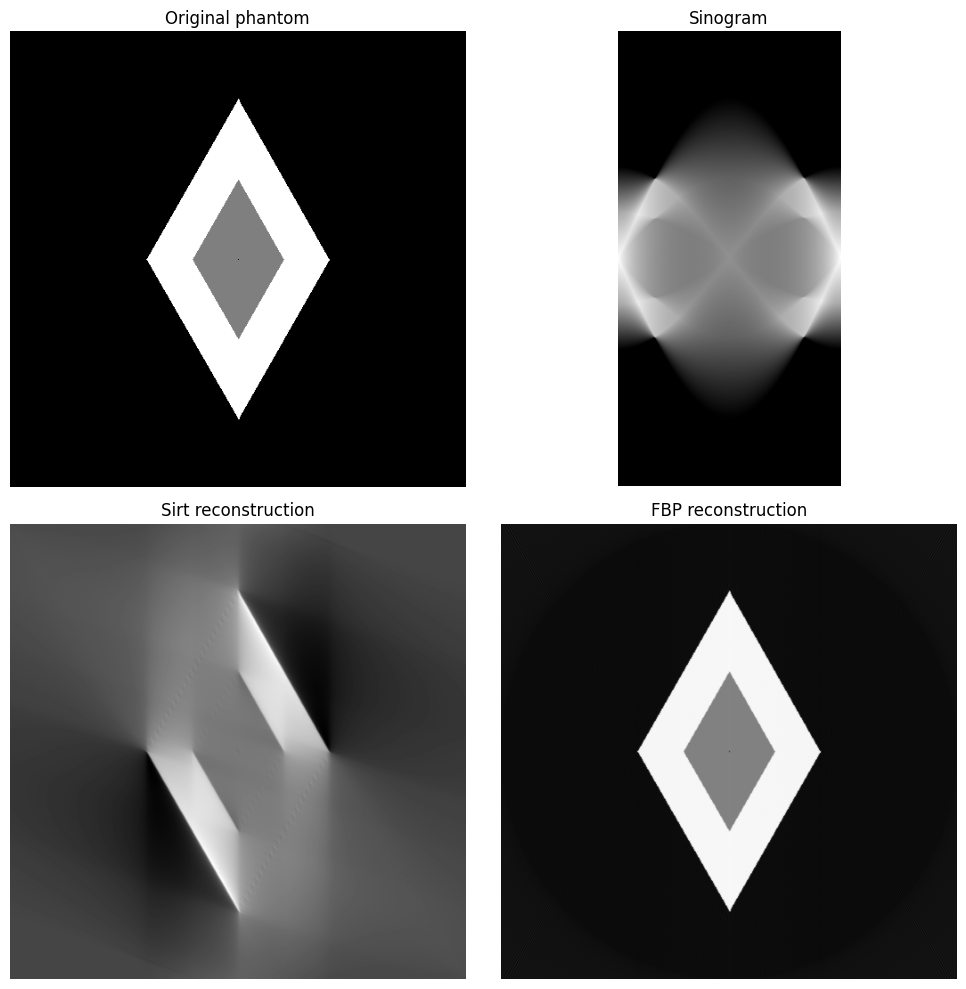

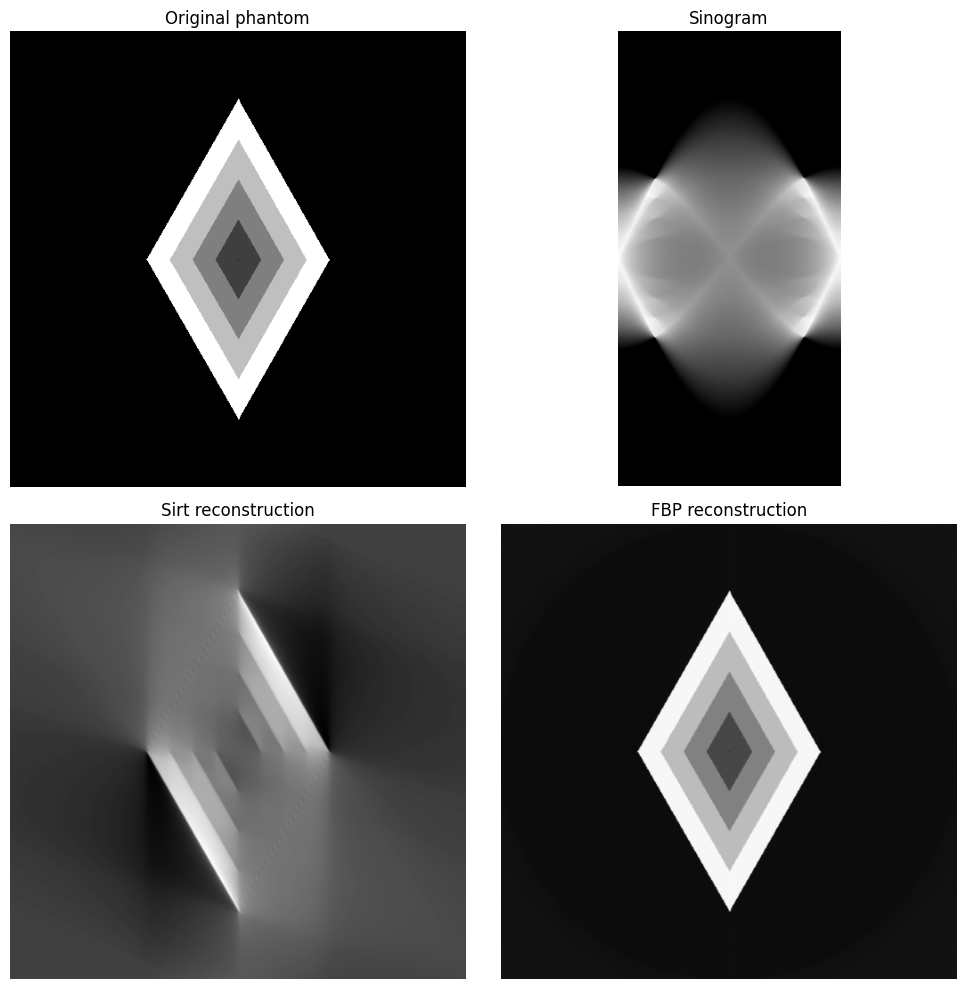

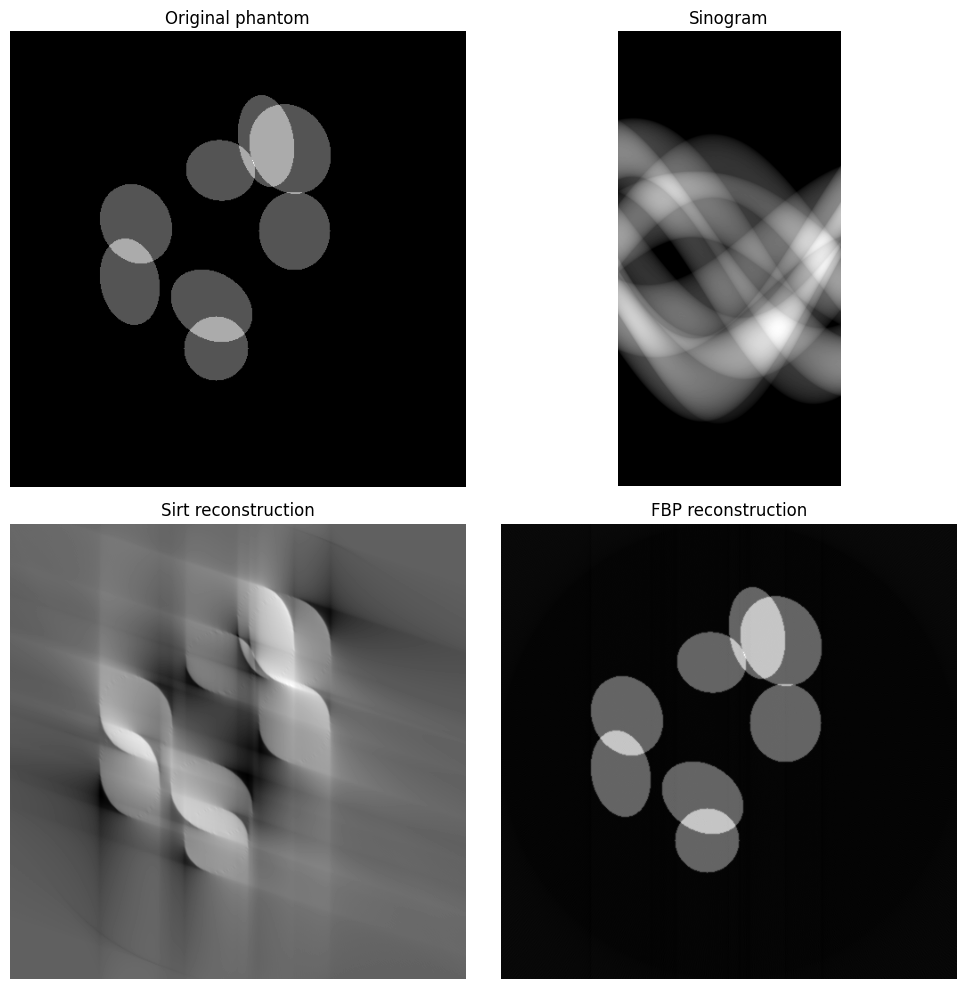

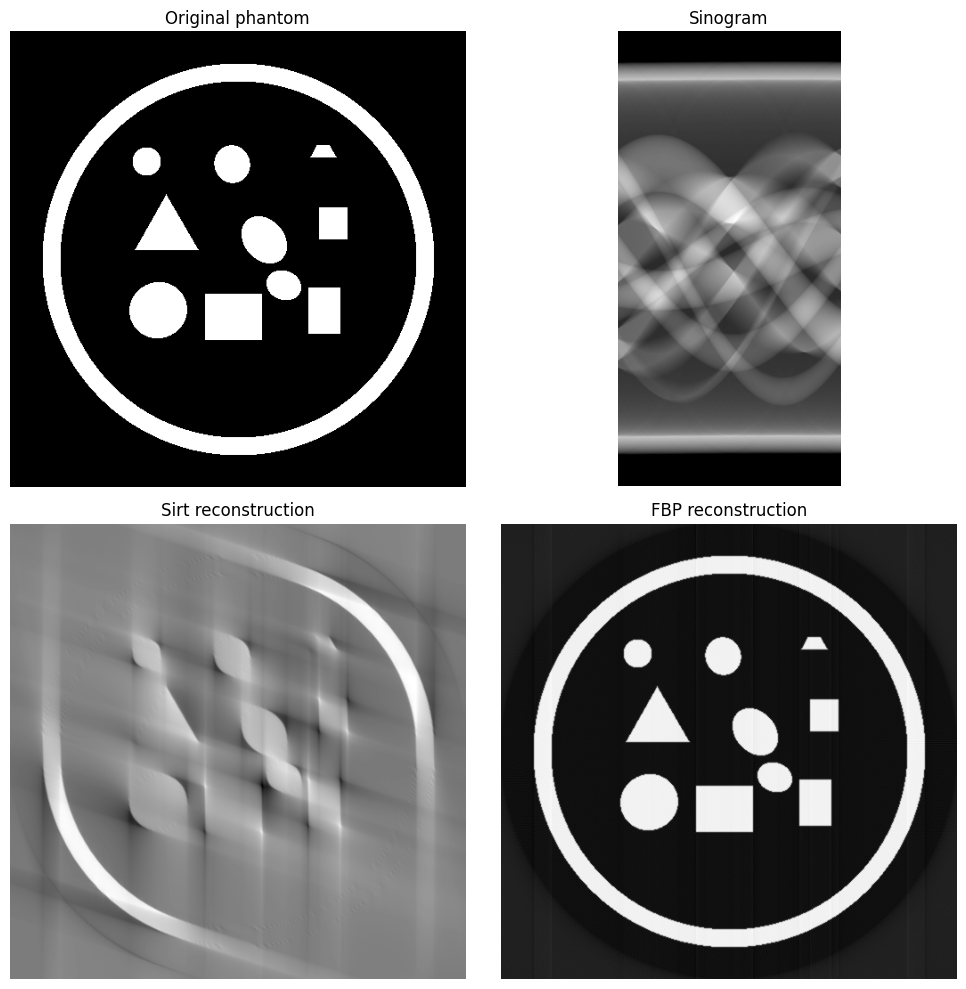

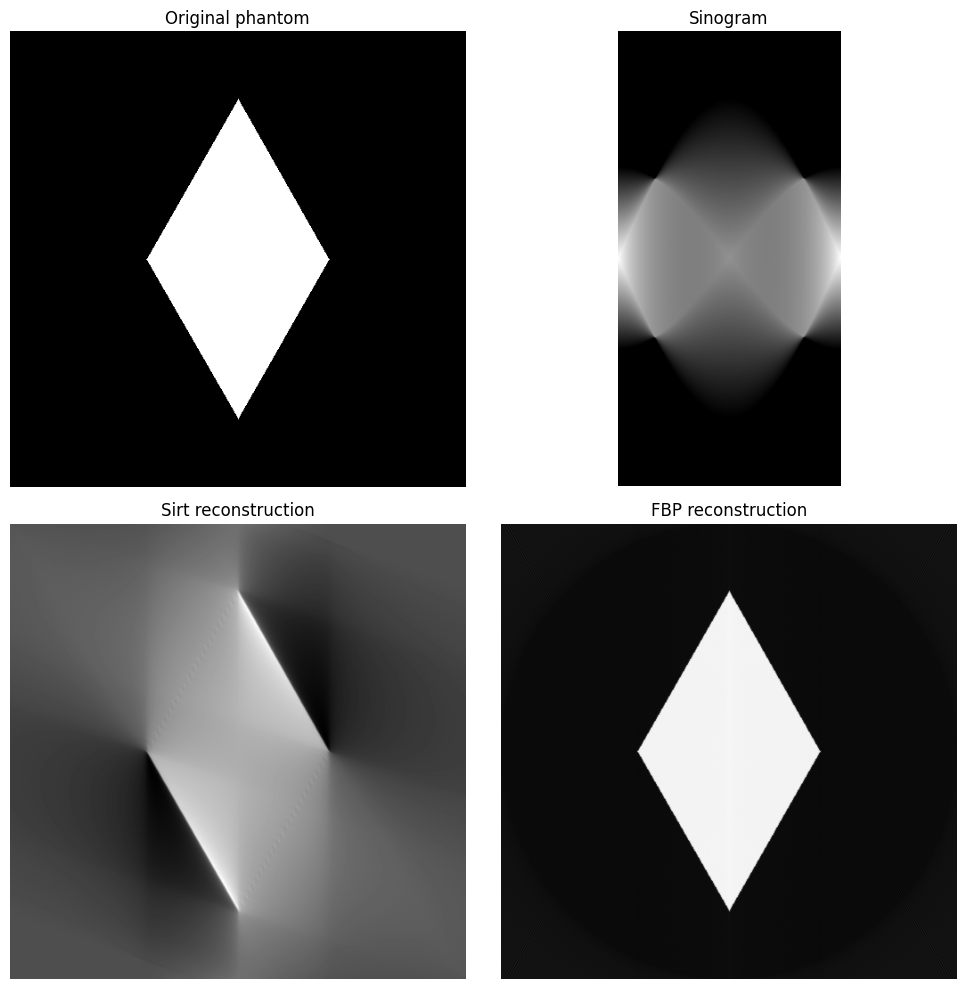

In [ ]:
n_projections = 180
n_detectors = 512
angles = np.linspace(0, np.pi, n_projections)
detector_spacing = 1

results = {}
for name, img in phantoms.items():
    
    proj_id, sino_id, sino_data, vol_geom, proj_geom = sinogram(
        phantom=img,
        n_projections=n_projections,
        n_detectors=n_detectors,
        angles=angles,
        detector_spacing=detector_spacing
    )
    _, fbp_res = FBP(vol_geom, sino_id, proj_geom, sino_data, use_gpu=False)

    _, sirt_res = SIRT(vol_geom=vol_geom,
                              proj_geom=proj_geom,
                              sinogram=sino_data,
                              projector_id=proj_id,
                              vol_data=0,
                              iters=200,
                              use_gpu=False)

    plot(
        phantom=img,
        sinogram_img=sino_data.T,
        sirt_reconstruction=sart_res,
        fbp_reconstruction=fbp_res
    )